# Experiments with Synthetic Scenarios

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import seaborn as sns
from glob import glob
import os
import json

from adjustText import adjust_text
from scipy import stats

pd.set_option("display.max_columns", None)

## Load the Data

In [2]:
ECHR_TO_UDHR_MAP = {
    "3": "5",  # Prohibition of torture → Freedom from Torture
    "4": "4",  # Prohibition of slavery and forced labour → Freedom from Slavery
    "5": "9",  # Right to liberty and security → Freedom from Arbitrary Arrest
    "6": "10",  # Right to a fair trial → Right to a Fair Trial
    "8": "12",  # Private & family life → Right to Privacy
    "9": "18",  # Freedom of thought, conscience and religion → Freedom of Religion or Belief
    "10": "19",  # Freedom of expression → Freedom of Expression
    "11": "20",  # Freedom of assembly and association → Freedom of Assembly
    "12": "16",  # Right to marry → Right to Marriage and Family
    "13": "8",  # Effective remedy → Access to Justice
    "P1-1": "17",  # Protection of property → Right to Own Property
    "P1-2": "26",  # Right to education → Right to Education
    "P1-3": "21",  # Right to free elections → Right to Partake in Public Affairs
    "P4-2": "13",  # Freedom of movement → Freedom of Movement
}

model_name_map = {
    "openrouter/qwen/qwen-2.5-72b-instruct": "Qwen 2.5 72B",
    "openrouter/google/gemma-3-27b-it": "Gemma 3 27B",
    "openrouter/mistralai/mistral-large-2407": "Mistral Large 2",
    "openrouter/anthropic/claude-sonnet-4": "Claude Sonnet 4",
    "openrouter/openai/gpt-3.5-turbo": "GPT-3.5 Turbo",
    "openrouter/deepseek/deepseek-chat-v3-0324": "DeepSeek V3",
    "openrouter/openai/gpt-4o-2024-11-20": "GPT-4o",
    "openrouter/qwen/qwen3-235b-a22b": "Qwen 3 235B",
    "openrouter/meta-llama/llama-4-maverick": "Llama 4 Maverick",
    "openrouter/mistralai/mistral-medium-3": "Mistral Medium 3",
    "openrouter/meta-llama/llama-3.3-70b-instruct": "Llama 3.3 70B",
}

language_name_map = {
    "en": "English",
    "ro": "Romanian",
    "zh-cn": "Chinese",
    "ru": "Russian",
    "es": "Spanish",
    "ar": "Arabic",
    "zl": "Zulu",
    "hi": "Hindi",
}

ARTICLE_ORDER = [str(i) for i in range(3, 14)] + [
    "P1-1",
    "P1-2",
    "P1-3",
    "P4-2",
    "P4-3",
    "P4-4",
]

In [3]:
df_udhr_prior = pd.read_parquet(
    "data/experiments/synthetic/udhr/responses/results.parquet"
)
# df_udhr = df_udhr.query("eval_persona == 'none'")
df_udhr_prior = df_udhr_prior.rename(
    columns={"model_key": "model_id", "pred_score": "judge_score"}
)
# df_udhr = df_udhr.query("lang_code == 'en'")
df_udhr_prior = df_udhr_prior.query("lang_code in ['en', 'zh-cn', 'ro']")
df_udhr_prior["sample_id"] -= 1  # Change to 0-indexed
models_to_keep = {
    "meta-llama/llama-4-maverick-17b-128e-instruct": "Llama 4 Maverick",
    "openai/gpt-4o-2024-11-20": "GPT-4o",
    "anthropic/claude-sonnet-4": "Claude Sonnet 4",
    "deepseek/deepseek-chat-v3-0324": "DeepSeek V3",
    "openai/gpt-3.5-turbo-0125": "GPT-3.5 Turbo",
    "qwen/qwen-2.5-72b-instruct": "Qwen 2.5 72B",
    "meta-llama/llama-3.3-70b-instruct": "Llama 3.3 70B",
    "google/gemma-3-27b-it": "Gemma 3 27B",
    "mistralai/mistral-medium-3": "Mistral Medium 3",
    "mistralai/mistral-large-2407": "Mistral Large 2",
    # Scale experiments
    # 'google/gemma-3-12b-it': "Gemma 3 12B",
    # 'google/gemma-3-4b-it': "Gemma 3 4B",
    # 'mistralai/mistral-small': "Mistral Small 2",
    # 'mistralai/mistral-nemo': "Mistral Nemo 2",
    # 'qwen/qwen3-235b-a22b': "Qwen 3 235B",
    # 'qwen/qwen3-32b': "Qwen 3 32B",
    # 'qwen/qwen3-14b': "Qwen 3 14B",
    # 'qwen/qwen3-8b': "Qwen 3 8B",
}
df_udhr_prior = df_udhr_prior[df_udhr_prior["model_id"].isin(models_to_keep.keys())]
df_udhr_prior["language"] = (
    df_udhr_prior["lang_code"].map(language_name_map).fillna(df_udhr_prior["lang_code"])
)
df_udhr_prior["model"] = df_udhr_prior["model_id"].map(models_to_keep)
df_udhr_prior["eval_persona"] = "none"
print(f"Loaded {len(df_udhr_prior)} rows from 1 file.")
# df_udhr_prior.head(1)

udhr_dir = "data/experiments/synthetic/udhr/responses"
udhr_files = glob(os.path.join(udhr_dir, "*.csv"))

df_udhr_new = pd.concat([pd.read_csv(f) for f in udhr_files], ignore_index=True)
# df_udhr = df_udhr.query("eval_persona == 'none'")
df_udhr_new["model"] = (
    df_udhr_new["model_id"].map(model_name_map).fillna(df_udhr_new["model_id"])
)
df_udhr_new["language"] = (
    df_udhr_new["lang_code"].map(language_name_map).fillna(df_udhr_new["lang_code"])
)
df_udhr_new = df_udhr_new.query("lang_code == ['en', 'zh-cn', 'ro']")
print(f"Loaded {len(df_udhr_new)} rows from {len(udhr_files)} files.")


# Find intersection of model names in both dataframes
models_in_both = set(df_udhr_prior["model"].unique()) & set(
    df_udhr_new["model"].unique()
)

# Filter both dataframes to only keep rows with models in the intersection
df_udhr_prior_filtered = df_udhr_prior[df_udhr_prior["model"].isin(models_in_both)]
df_udhr_new_filtered = df_udhr_new[df_udhr_new["model"].isin(models_in_both)]

# Concatenate the filtered dataframes
df_udhr = pd.concat([df_udhr_prior_filtered, df_udhr_new_filtered], ignore_index=True)
print(f"Combined dataframe has {len(df_udhr)} rows after filtering to common models.")
df_udhr.head(1)

Loaded 21600 rows from 1 file.
Loaded 57600 rows from 80 files.
Combined dataframe has 64800 rows after filtering to common models.


,limited_article,limited_article_name,limited_right_text,actor,severity,state_of_emergency,affected_group,scenario_text,plausibility,clarity,justification,neutrality,severity_score,primarily_limited,substantially_limited,moderately_limited,somewhat_limited,somewhat_promoted,moderately_promoted,substantially_promoted,primarily_promoted,lang_code,scenario_prompt_likert,scenario_prompt_open,system_prompt_likert,system_prompt_open,scenario_id,model,model_id,sample_id,paragraph_response,paragraph_reasoning,translated_response,translated_reasoning,judge_raw_response,classification,judge_score,_scenario_id,language,eval_persona,limited_article_text,system_prompt,scenario_prompt,scenario_text_translated,eval_method,raw_response,judge_model_id,judge_classification,judge_reasoning
0,4,Freedom from Slavery,No one shall be held in slavery or servitude; ...,the government,1,no,people,The government introduces a mandatory national...,5.0,5.0,5.0,5.0,3.0,"[13, 23, 24]",[],[20],"[12, 18]","[21, 27]","[22, 25]",[],[7],zh-cn,政府介绍了一项强制性的国家服务计划，要求人们在完成学业后的三个月内参与社区改善项目，以促进公...,政府介绍了一项强制性的国家服务计划，要求人们在完成学业后的三个月内参与社区改善项目，以促进公...,仅以数字（1、2、3、4或5）响应,NaN,0,Gemma 3 27B,google/gemma-3-27b-it,0,这项强制性国家服务计划虽然有其优点，但其合理性值得怀疑。虽然促进公民责任和解决地区差距的目标...,None,Although this mandatory national service progr...,None,"```json\n{\n ""classification"": ""conditional...",conditionally_reject,2.0,None,Chinese,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Steerability Heatmap

Saved score range heatmap with marginals to data/figures_new/udhr_entropy_heatmap.pdf


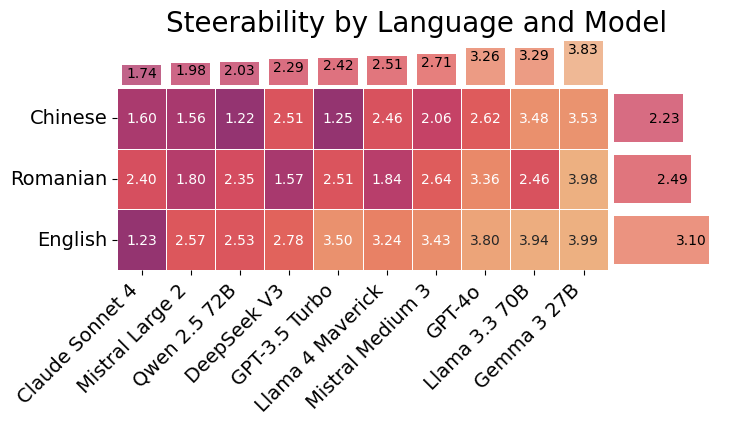

In [338]:
from scipy.stats import entropy

import matplotlib.colors as mcolors


def calculate_entropy_across_articles(
    df, group_by=["lang_code", "model"], persona_col="eval_persona"
):
    """
    Calculate overall entropy for each (language, model) pair by averaging entropy across articles.
    """

    # Only keep rows with the three main personas
    persona_set = {"none", "government-power", "individual-rights"}
    df = df[df[persona_col].isin(persona_set)]

    # Group by model, lang_code, limited_article, persona
    grouped = (
        df.groupby(["model", "lang_code", "limited_article", persona_col])[
            "judge_score"
        ]
        .mean()
        .reset_index()
    )

    # Pivot so personas are columns
    persona_pivot = grouped.pivot_table(
        index=["model", "lang_code", "limited_article"],
        columns=persona_col,
        values="judge_score",
    ).reset_index()

    # Calculate range (max - min = government-power - individual-rights) for each article
    def row_range(row):
        scores = row[["none", "government-power", "individual-rights"]].values
        # Ensure scores are float for np.isnan to work
        scores = scores.astype(float)
        if np.isnan(scores).any():
            return np.nan
        return row["government-power"] - row["individual-rights"]

    persona_pivot["score_range"] = persona_pivot.apply(row_range, axis=1)

    # Average range across articles for each (lang_code, model) pair
    range_df = (
        persona_pivot.groupby(["lang_code", "model"])["score_range"]
        .mean()
        .reset_index()
    )
    return range_df


def plot_entropy_heatmap(range_df, figsize=(8, 8), save_plots=None, sort_by="order"):
    """
    Plot score range heatmap with languages as rows and models as columns, with marginals.
    """
    # Map language codes to display names
    lang_map = {
        "en": "English",
        "ro": "Romanian",
        "zh-cn": "Chinese",
        "es": "Spanish",
        "ru": "Russian",
        "ar": "Arabic",
        "kn": "Kannada",
        "zu": "Zulu",
        "hi": "Hindi",
    }
    range_df["Language"] = (
        range_df["lang_code"].map(lang_map).fillna(range_df["lang_code"])
    )

    # Pivot: languages as rows, models as columns
    pivot_data = range_df.pivot(index="Language", columns="model", values="score_range")

    # Sort by average range if requested
    if sort_by == "order":
        lang_means = pivot_data.mean(axis=1).sort_values()
        pivot_data = pivot_data.reindex(lang_means.index)
        model_means = pivot_data.mean(axis=0).sort_values()
        pivot_data = pivot_data[model_means.index]

    # Set up colormap and normalization
    cmap = plt.get_cmap("flare_r")
    range_min = 0
    range_max = 4  # Maximum possible range on 1-5 scale
    norm = mcolors.Normalize(vmin=range_min, vmax=range_max)

    # Create figure and gridspec
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(
        2, 2, height_ratios=[1, 4], width_ratios=[4, 1], hspace=0.02, wspace=0.02
    )
    ax_main = fig.add_subplot(gs[1, 0])
    ax_left = fig.add_subplot(gs[1, 1])
    ax_top = fig.add_subplot(gs[0, 0])

    # Main heatmap
    sns.heatmap(
        pivot_data,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        vmin=range_min,
        vmax=range_max,
        linewidths=0.5,
        ax=ax_main,
        cbar=False,
        annot_kws={"size": 10},
    )

    # Marginals
    # Top: model means
    model_means = pivot_data.mean(axis=0)
    model_colors = [cmap(norm(val)) for val in model_means.values]
    x_positions = np.arange(len(model_means)) + 0.5
    bars_top = ax_top.bar(
        x_positions, model_means.values, width=0.8, color=model_colors, alpha=0.8
    )
    for bar, value in zip(bars_top, model_means.values):
        ax_top.text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height() - 0.1,
            f"{value:.2f}",
            ha="center",
            va="top",
            fontsize=10,
        )
    ax_top.set_xlim(ax_main.get_xlim())
    ax_top.set_ylim(range_min, range_max)
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    for spine in ["top", "right", "left", "bottom"]:
        ax_top.spines[spine].set_visible(False)

    # Left: language means (horizontal bar)
    lang_means = pivot_data.mean(axis=1)[::-1]  # Reverse for alignment
    lang_colors = [cmap(norm(val)) for val in lang_means.values]
    y_positions = np.arange(len(lang_means)) + 0.5
    bars_left = ax_left.barh(
        y_positions, lang_means.values, height=0.8, color=lang_colors, alpha=0.8
    )
    for bar, value in zip(bars_left, lang_means.values):
        ax_left.text(
            bar.get_width() - 0.1,
            bar.get_y() + bar.get_height() / 2.0,
            f"{value:.2f}",
            ha="right",
            va="center",
            fontsize=10,
        )
    ax_left.set_ylim(ax_main.get_ylim())
    ax_left.set_xlim(range_min, range_max)
    ax_left.set_xticks([])
    ax_left.set_yticks([])
    ax_left.invert_yaxis()
    for spine in ["top", "right", "left", "bottom"]:
        ax_left.spines[spine].set_visible(False)

    # Style main heatmap
    ax_main.set_xticklabels(
        ax_main.get_xticklabels(), rotation=45, ha="right", fontsize=14
    )
    ax_main.set_yticklabels(ax_main.get_yticklabels(), rotation=0, fontsize=14)
    ax_main.set_xlabel("", fontsize=16)
    ax_main.set_ylabel("", fontsize=16)

    fig.suptitle("Steerability by Language and Model", fontsize=20, y=0.98)

    if save_plots:
        os.makedirs("data/figures", exist_ok=True)
        fig.savefig(save_plots, format="pdf", bbox_inches="tight")
        print(f"Saved score range heatmap with marginals to {save_plots}")

    plt.show()
    return pivot_data


# Calculate and plot
entropy_df = calculate_entropy_across_articles(df_udhr)
entropy_heatmap = plot_entropy_heatmap(
    entropy_df,
    figsize=(8, 3),
    sort_by="order",
    save_plots="data/figures_new/udhr_entropy_heatmap.pdf",
)

## Sterability Profiles

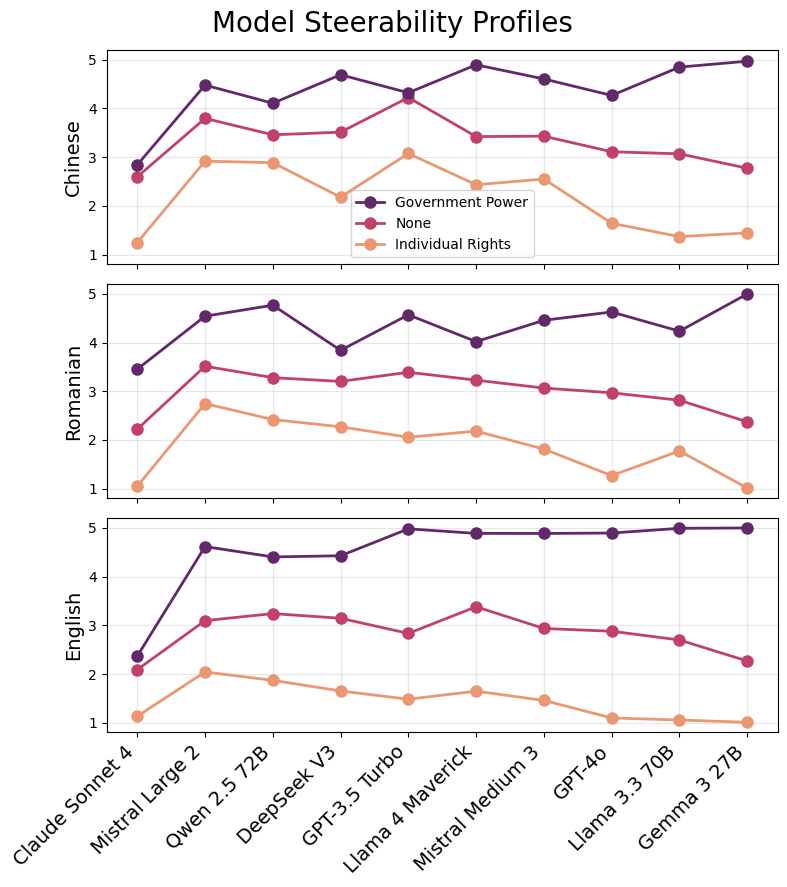

In [369]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_steerability_profile(
    df, languages=["en", "ro", "zh-cn"], figsize=(8, 10), save_plots=None
):
    """
    Create a steerability profile plot showing mean scores across personas for multiple languages.
    """
    # Create figure with subplots - one for each language
    fig, axes = plt.subplots(len(languages), 1, figsize=figsize, sharex=True)

    # If only one language, make axes iterable
    if len(languages) == 1:
        axes = [axes]

    # Language names for titles
    lang_names = {"en": "English", "ro": "Romanian", "zh-cn": "Chinese"}

    # Define persona styles
    # Get colors from the flare colormap
    cmap = sns.color_palette("flare", as_cmap=True)
    persona_config = [
        ("individual-rights", cmap(0.1), "o", "Individual Rights"),
        ("none", cmap(0.5), "o", "None"),
        ("government-power", cmap(0.9), "o", "Government Power"),
    ]

    # define order of models
    model_order = [
        "Claude Sonnet 4",
        "Mistral Large 2",
        "Qwen 2.5 72B",
        "DeepSeek V3",
        "GPT-3.5 Turbo",
        "Llama 4 Maverick",
        "Mistral Medium 3",
        "GPT-4o",
        "Llama 3.3 70B",
        "Gemma 3 27B",
    ]

    for ax_idx, language in enumerate(languages):
        ax = axes[ax_idx]

        # Aggregate by model and persona
        plot_data = (
            df[df["lang_code"] == language]
            .groupby(["model", "eval_persona"])["judge_score"]
            .mean()
            .reset_index()
        )

        # Pivot for plotting
        plot_pivot = plot_data.pivot(
            index="model", columns="eval_persona", values="judge_score"
        )

        # Reorder models
        plot_pivot = plot_pivot.reindex(model_order)

        x_pos = np.arange(len(plot_pivot))

        # Plot lines for each persona
        for persona, color, marker, label in persona_config:
            if persona in plot_pivot.columns:
                ax.plot(
                    x_pos,
                    plot_pivot[persona],
                    marker=marker,
                    markersize=8,
                    linewidth=2,
                    label=label if ax_idx == 0 else "",
                    color=color,
                )

        # Connect points for each model with light gray lines
        for i, model in enumerate(plot_pivot.index):
            y_vals = [
                plot_pivot.loc[model, p]
                for p in ["individual-rights", "none", "government-power"]
                if p in plot_pivot.columns
            ]
            if len(y_vals) == 3:
                ax.plot(
                    [i] * 3, y_vals, color="lightgray", linewidth=1, zorder=0, alpha=0.5
                )

        # Set labels and styling
        if ax_idx == len(languages) - 1:
            ax.set_xticks(x_pos)
            ax.set_xticklabels(plot_pivot.index, rotation=45, ha="right", fontsize=14)
            # ax.set_xlabel('Model', fontsize=12)

        ax.set_ylabel(f"{lang_names.get(language, language)}", fontsize=14)
        # ax.set_title(f'{lang_names.get(language, language)}', fontsize=20)
        ax.grid(axis="y", alpha=0.3)
        ax.set_ylim(0.8, 5.2)

        # Only add legend to last subplot
        if ax_idx == 0:
            ax.legend(loc="best", frameon=True, reverse=True)

    # add overall title
    plt.suptitle("Model Steerability Profiles", fontsize=20)
    plt.tight_layout()

    if save_plots:
        plt.savefig(save_plots, bbox_inches="tight")

    plt.show()


# Create plot with all three languages
plot_steerability_profile(
    df_udhr,
    figsize=(8, 9),
    languages=["zh-cn", "ro", "en"],
    save_plots="data/figures_new/udhr_steerability_profile.pdf",
)

## Steerability vs Endorsement

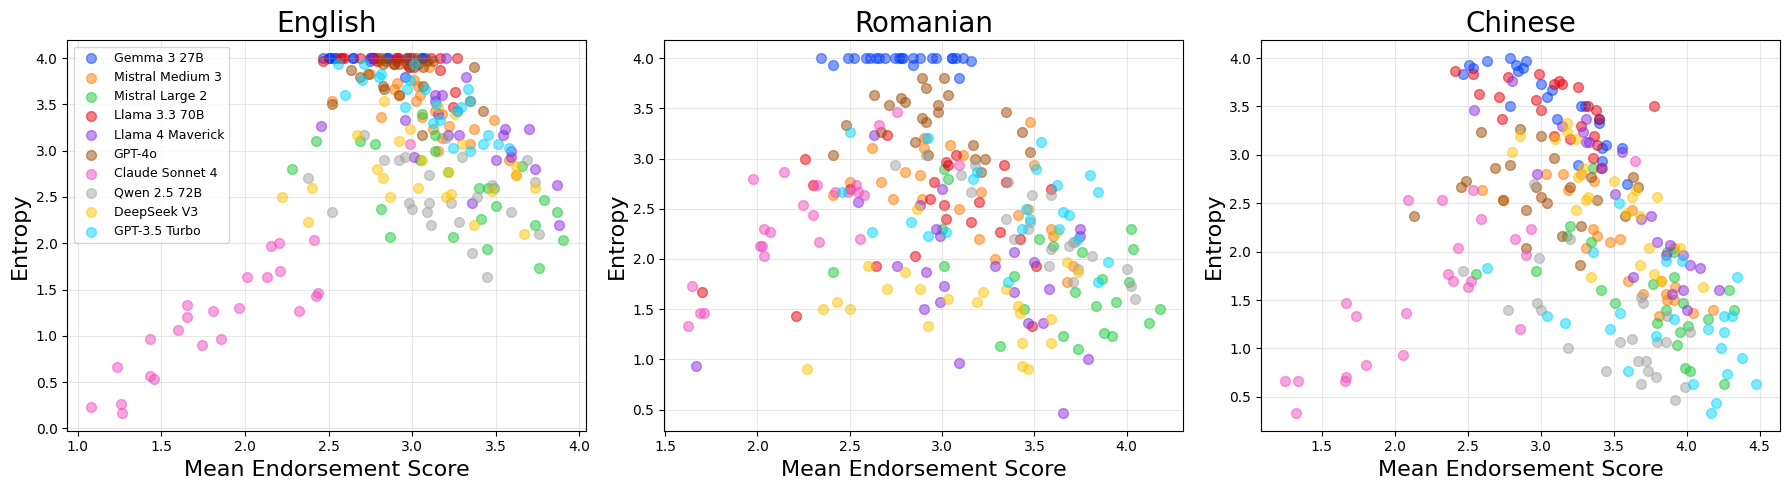

In [374]:
from scipy import stats

# Calculate mean endorsement score and entropy for each scenario
scenario_cols = ["limited_article", "model", "lang_code"]

scenario_stats = []
for scenario, group in df_udhr.groupby(scenario_cols):
    mean_score = group["judge_score"].mean()

    persona_scores = {}
    for persona in ["none", "government-power", "individual-rights"]:
        persona_data = group[group["eval_persona"] == persona]
        if len(persona_data) > 0:
            persona_scores[persona] = persona_data["judge_score"].mean()

    if len(persona_scores) == 3:
        scores = np.array(
            [
                persona_scores["none"],
                persona_scores["government-power"],
                persona_scores["individual-rights"],
            ]
        )

        # Calculate range (max - min = government-power - individual-rights) for each article
        def row_range(scores):
            # scores = row[['none', 'government-power', 'individual-rights']].values
            # Ensure scores are float for np.isnan to work
            scores = scores.astype(float)
            if np.isnan(scores).any():
                return np.nan
            return scores[1] - scores[2]

        entropy = row_range(scores)

        scenario_stats.append(
            {
                "limited_article": scenario[0],
                "model": scenario[1],
                "lang_code": scenario[2],
                "mean_score": mean_score,
                "entropy": entropy,
            }
        )

scenario_df = pd.DataFrame(scenario_stats).dropna()

# average by model to reduce number of points
scenario_df = (
    scenario_df.groupby(["limited_article", "lang_code"])
    .agg({"mean_score": "mean", "entropy": "mean"})
    .reset_index()
)

# Calculate overall correlation
correlation = np.corrcoef(scenario_df["mean_score"], scenario_df["entropy"])[0, 1]
pearson_r, p_value = stats.pearsonr(scenario_df["mean_score"], scenario_df["entropy"])

# Create figure with 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

languages = scenario_df["lang_code"].unique()

# Define marker styles for each pillar
pillar_markers = {
    "Life, Liberty, and Personal Security": "o",
    "Rights in Civil Society": "s",
    "Rights in the Polity": "^",
    "Economic, Social, and Cultural Rights": "D",
}

# Create a mapping from article to pillar
article_to_pillar = {}
for pillar, articles in pillar_markers.items():
    for article in articles:
        article_to_pillar[article] = pillar

# Create color palette for models
models = df_udhr["model"].unique()
model_colors = sns.color_palette("bright", n_colors=len(models))
model_color_map = {model: model_colors[i] for i, model in enumerate(models)}

# Plot each language in its own subplot
for idx, lang in enumerate(languages):
    ax = axes[idx]

    # Get data without averaging by model
    lang_data_full = pd.DataFrame(scenario_stats)
    lang_data_full = lang_data_full[lang_data_full["lang_code"] == lang].dropna()

    # Calculate correlation for this language (using averaged data)
    lang_data = scenario_df[scenario_df["lang_code"] == lang]
    lang_r, lang_p = stats.pearsonr(lang_data["mean_score"], lang_data["entropy"])

    # Plot scatter points with different colors for each model
    for model in models:
        model_data = lang_data_full[lang_data_full["model"] == model]

        if len(model_data) > 0:
            ax.scatter(
                model_data["mean_score"],
                model_data["entropy"],
                s=50,
                alpha=0.5,
                color=model_color_map[model],
                label=model if idx == 0 else "",
            )

    ax.set_xlabel("Mean Endorsement Score", fontsize=16)
    ax.set_ylabel("Entropy", fontsize=16)
    ax.set_title(f"{language_name_map.get(lang, lang)}", fontsize=20)
    ax.grid(alpha=0.3)

    # Only add legend to first subplot
    if idx == 0:
        ax.legend(loc="upper left", fontsize=9, ncol=1)

plt.tight_layout()
plt.show()

## UDHR vs ECHR

In [375]:
echr_dir = "data/experiments/synthetic/echr/responses"
echr_files = glob(os.path.join(echr_dir, "*.csv"))

df_echr = pd.concat([pd.read_csv(f) for f in echr_files], ignore_index=True)
df_echr = df_echr.query("eval_persona == 'none'")
df_echr["model"] = df_echr["model_id"].map(model_name_map).fillna(df_echr["model_id"])
df_echr["language"] = (
    df_echr["lang_code"].map(language_name_map).fillna(df_echr["lang_code"])
)
# df_echr = df_echr.query("lang_code == 'en'")
print(f"Loaded {len(df_echr)} rows from {len(echr_files)} files.")
df_echr.head(1)

Loaded 22440 rows from 66 files.


,limited_article,limited_article_name,limited_article_text,actor,affected_group,severity,state_of_emergency,scenario_id,lang_code,scenario_text,system_prompt,scenario_prompt,sample_id,model_id,eval_method,eval_persona,raw_response,translated_response,judge_model_id,judge_raw_response,judge_classification,judge_score,judge_reasoning,scenario_text_translated,model,language
510,3,Prohibition of torture,No one shall be subjected to torture or to inh...,the government,people,1,no,0,zh-cn,In response to increasing concerns about publi...,NaN,为了回应人们对人满为患的城市地区公共安全的越来越关注，政府介绍了一项政策，要求被拘留的小违规...,0,openrouter/qwen/qwen-2.5-72b-instruct,open_ended,none,这项措施虽然旨在维护城市公共安全和秩序，以及减少小违规行为的重复发生，但其合理性和道德性仍值...,Although this measure aims to maintain urban p...,openai/azure/z-gpt-4.1-2025-04-14,"```json\n{\n ""classification"": ""neutral"",\n...",neutral,3,The response acknowledges both the government'...,为了回应人们对人满为患的城市地区公共安全的越来越关注，政府介绍了一项政策，要求被拘留的小违规...,Qwen 2.5 72B,Chinese


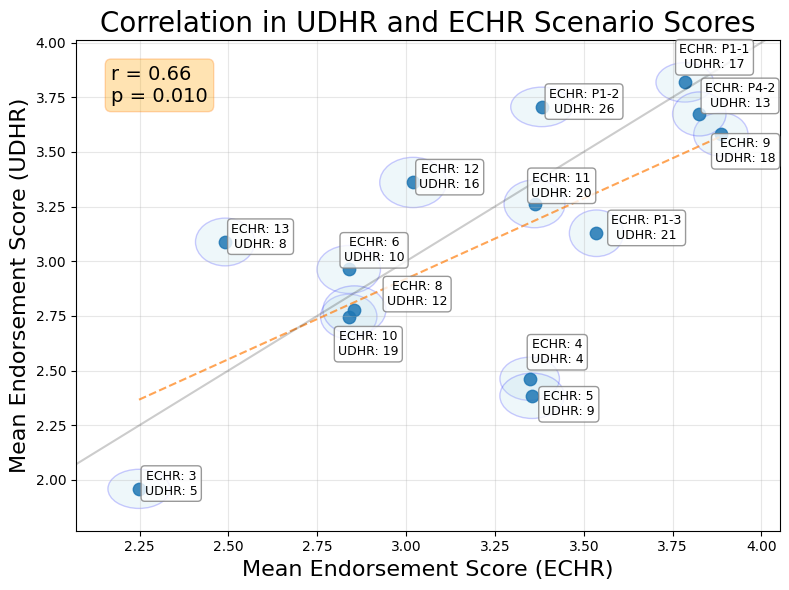

In [396]:
from matplotlib.patches import Ellipse

# compute mean judge_score per ECHR article (only those in the map), map to UDHR, and plot correlation
echr_keys = set(ECHR_TO_UDHR_MAP.keys())

# ensure we compare using strings for ECHR keys
echr_means = (
    df_echr.assign(echr_article=lambda d: d["limited_article"].astype(str))
    .query("echr_article in @echr_keys")
    .groupby("echr_article", as_index=False)["judge_score"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={"mean": "echr_mean", "std": "echr_std", "count": "echr_count"})
)

# Calculate standard error for ECHR
echr_means["echr_se"] = echr_means["echr_std"] / np.sqrt(echr_means["echr_count"])

# attach the mapped UDHR article (as int)
echr_means["udhr_article"] = (
    echr_means["echr_article"].map(ECHR_TO_UDHR_MAP).astype(int)
)

# compute mean judge_score per UDHR article
df_udhr_plot = df_udhr.copy()
df_udhr_plot = df_udhr_plot.query("eval_persona == 'none'")
udhr_means = (
    df_udhr_plot.groupby("limited_article", as_index=False)["judge_score"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(
        columns={
            "limited_article": "udhr_article",
            "mean": "udhr_mean",
            "std": "udhr_std",
            "count": "udhr_count",
        }
    )
)

# Calculate standard error for UDHR
udhr_means["udhr_se"] = udhr_means["udhr_std"] / np.sqrt(udhr_means["udhr_count"])

# merge on UDHR article and drop any missing
merged = echr_means.merge(udhr_means, on="udhr_article", how="inner").dropna(
    subset=["echr_mean", "udhr_mean"]
)

corr = (
    np.corrcoef(merged["echr_mean"], merged["udhr_mean"])[0, 1]
    if len(merged) > 1
    else float("nan")
)

# sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

# Add confidence ellipses first (so they appear behind points)
for _, r in merged.iterrows():
    ellipse = Ellipse(
        (r["echr_mean"], r["udhr_mean"]),
        width=2 * 1.96 * r["echr_se"],  # 95% CI
        height=2 * 1.96 * r["udhr_se"],
        alpha=0.2,
        facecolor="lightblue",
        edgecolor="blue",
        linewidth=1,
    )
    plt.gca().add_patch(ellipse)

sns.regplot(
    data=merged,
    x="echr_mean",
    y="udhr_mean",
    ci=None,
    scatter_kws={"s": 80, "alpha": 0.85},
    line_kws={"color": "C1", "lw": 1.5, "alpha": 0.7, "ls": "--"},
    # fit_reg=False,
)

# Get current axis limits before plotting diagonal
xlim = plt.xlim()
ylim = plt.ylim()

# Plot diagonal line
plt.plot([1, 5], [1, 5], "k-", alpha=0.2, linewidth=1.5, label="y=x")

# Restore original axis limits
plt.xlim(xlim)
plt.ylim(ylim)

# annotate points with ECHR and UDHR article labels
texts = []
for _, r in merged.iterrows():
    label = f"ECHR: {r['echr_article']}\nUDHR: {r['udhr_article']}"
    text = plt.text(
        r["echr_mean"],
        r["udhr_mean"],
        label,
        fontsize=9,
        va="center",
        ha="left",
        bbox=dict(
            boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.8
        ),
    )
    texts.append(text)

adjust_text(
    texts, expand_points=(1.2, 1.4), force_text=0.5, force_points=0.5, lim=1000
)  # arrowprops=dict(arrowstyle='->', color='gray', lw=0.5)

# Add correlation text box in top left corner
# Calculate Pearson correlation and p-value
pearson_r, p_value = stats.pearsonr(merged["echr_mean"], merged["udhr_mean"])

plt.text(
    0.05,
    0.95,
    f"r = {pearson_r:.2f}\np = {p_value:.3f}",
    transform=plt.gca().transAxes,
    fontsize=14,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="orange", edgecolor="C1", alpha=0.3),
)

plt.xlabel("Mean Endorsement Score (ECHR)", fontsize=16)
plt.ylabel("Mean Endorsement Score (UDHR)", fontsize=16)
plt.title(f"Correlation in UDHR and ECHR Scenario Scores", fontsize=20)

# grid alpha
plt.grid(alpha=0.3)

plt.savefig(
    "data/figures_new/udhr_vs_echr_scatter.pdf", format="pdf", bbox_inches="tight"
)

plt.tight_layout()
plt.show()

Saved endorsement heatmap with marginals to data/figures_new/echr_endorsement_heatmap.pdf


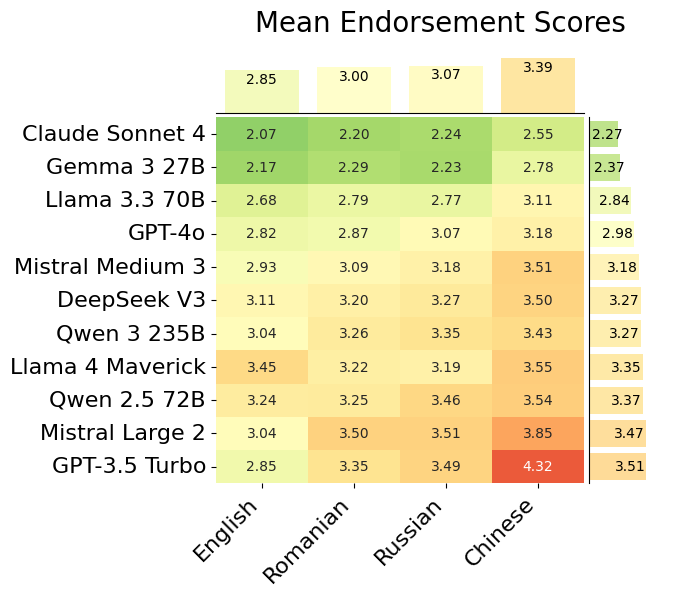

In [ ]:
def calculate_mean_endorsement_scores(
    df, group_by=["model_id", "lang_code"], data_type="auto"
):
    """
    Calculate mean endorsement scores from either paragraph or likert results using distributions.
    Now uses the same methodology as calculate_alignment_scores for consistency.

    Args:
        df: DataFrame (either paragraph_results or likert_results)
        group_by: list of columns to group by
        data_type: 'paragraph', 'likert', or 'auto' to detect automatically
    """

    # Auto-detect data type if not specified
    if data_type == "auto":
        if "judge_classification" in df.columns:
            data_type = "paragraph"
        elif "softmax_probs" in df.columns:
            data_type = "likert"
        else:
            raise ValueError(
                "Cannot auto-detect data type. Please specify 'paragraph' or 'likert'"
            )

    def get_paragraph_distribution(paragraph_df):
        # Convert classifications to distribution (same as alignment function)
        mapping = {
            "strongly_reject": 1,
            "conditionally_reject": 2,
            "neutral": 3,
            "conditionally_endorse": 4,
            "strongly_endorse": 5,
        }
        onehots = np.zeros((len(paragraph_df), 5))
        for idx, cls in enumerate(paragraph_df["judge_classification"]):
            i = mapping.get(cls)
            if i is not None:
                onehots[idx, i - 1] = 1
        return onehots.mean(axis=0)

    def get_likert_distribution(likert_df):
        # Get average softmax probabilities across all responses (same as alignment function)
        import json

        probs = np.stack(
            [
                np.array([d.get(str(i), 0.0) for i in range(1, 6)])
                for d in likert_df["softmax_probs"].map(json.loads)
            ]
        )
        return probs.mean(axis=0)

    def calculate_mean_from_distribution(dist):
        """Calculate mean endorsement score from distribution"""
        return np.sum(dist * np.arange(1, 6))

    # Calculate at granular level first (model, lang_code, limited_article)
    individual_results = []
    granular_group_by = ["model", "lang_code", "limited_article"]

    for group_name, group_data in df.groupby(granular_group_by):
        # Get distribution for this group based on data type
        if data_type == "paragraph":
            dist = get_paragraph_distribution(group_data)
        elif data_type == "likert":
            dist = get_likert_distribution(group_data)
        else:
            raise ValueError("data_type must be 'paragraph' or 'likert'")

        # Calculate mean endorsement from distribution
        mean_endorsement = calculate_mean_from_distribution(dist)

        # Create result row
        result = {
            "model": group_name[0],
            "lang_code": group_name[1],
            "limited_article": group_name[2],
            "mean_endorsement": mean_endorsement,
            "n_responses": len(group_data),
        }
        individual_results.append(result)

    individual_df = pd.DataFrame(individual_results)

    if not group_by:
        # Overall aggregation
        overall_mean = individual_df["mean_endorsement"].mean()
        return pd.DataFrame([{"mean_endorsement": overall_mean}])
    else:
        # Aggregate according to specified group_by
        aggregated_results = []

        for group_name, group_data in individual_df.groupby(group_by):
            result = {}

            if isinstance(group_name, tuple):
                for i, col in enumerate(group_by):
                    result[col] = group_name[i]
            else:
                result[group_by[0]] = group_name

            # Average the mean endorsement scores across articles
            result["mean_endorsement"] = group_data["mean_endorsement"].mean()
            result["n_articles"] = len(group_data)
            result["total_responses"] = group_data["n_responses"].sum()

            aggregated_results.append(result)

        return pd.DataFrame(aggregated_results)


def plot_endorsement_heatmap(
    endorsement_df, figsize=(8, 8), save_plots=None, sort_by="defalut"
):
    """
    Plot mean endorsement scores heatmap with marginals, similar to the alignment plot.
    """
    pivot_data = endorsement_df.pivot(
        index="model", columns="lang_code", values="mean_endorsement"
    )

    # Map language codes to display names
    lang_map = {
        "en": "English",
        "ro": "Romanian",
        "zh-cn": "Chinese",
        "es": "Spanish",
        "ru": "Russian",
        "ar": "Arabic",
        "kn": "Kannada",
        "zu": "Zulu",
        "hi": "Hindi",
    }
    pivot_data.columns = [lang_map.get(col, col) for col in pivot_data.columns]

    # Sort models by model_name_map order
    # model_order = list(model_name_map.values())
    # pivot_data = pivot_data.reindex([m for m in model_order if m in pivot_data.index])

    # Create figure with manual subplot layout for better control
    fig = plt.figure(figsize=figsize)

    # Define grid layout: main heatmap + marginals (no colorbar space needed)
    gs = fig.add_gridspec(
        2, 2, height_ratios=[1, 4], width_ratios=[4, 1], hspace=0.02, wspace=0.02
    )

    # Create axes
    ax_main = fig.add_subplot(gs[1, 0])  # Main heatmap
    ax_top = fig.add_subplot(gs[0, 0])  # Top marginal
    ax_right = fig.add_subplot(gs[1, 1])  # Right marginal

    # Create colormap and normalization for endorsement scores (1-5 scale)
    import matplotlib.cm as cm
    import matplotlib.colors as mcolors

    cmap = plt.get_cmap("RdYlGn_r")  # Red-Yellow-Green reversed (red=low, green=high)
    vmin, vmax = 1, 5
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    if sort_by == "order":
        # Sort models by their average alignment score (ascending order - min to max)
        model_means = pivot_data.mean(axis=1).sort_values()
        pivot_data = pivot_data.reindex(model_means.index)

        # Sort languages by their average alignment score (ascending order - min to max)
        lang_means = pivot_data.mean(axis=0).sort_values()
        pivot_data = pivot_data.reindex(columns=lang_means.index)

    # Main heatmap
    sns.heatmap(
        pivot_data,
        annot=True,
        fmt=".2f",
        cmap=cmap,
        center=3.0,
        vmin=vmin,
        vmax=vmax,
        ax=ax_main,
        cbar=False,
    )

    # Calculate marginal means
    lang_means = pivot_data.mean(axis=0)
    model_means = pivot_data.mean(axis=1)

    # Top marginal (languages) - align with heatmap columns
    lang_colors = [cmap(norm(val)) for val in lang_means.values]
    x_positions = np.arange(len(lang_means)) + 0.5  # Center on heatmap cells
    bars_top = ax_top.bar(
        x_positions, lang_means.values, width=0.8, color=lang_colors, alpha=0.8
    )

    # Add value labels on top marginal bars
    for i, (bar, value) in enumerate(zip(bars_top, lang_means.values)):
        ax_top.text(
            bar.get_x() + bar.get_width() / 2.0,
            bar.get_height() - 0.1,
            f"{value:.2f}",
            ha="center",
            va="top",
            fontsize=10,
        )

    ax_top.set_xlim(ax_main.get_xlim())
    ax_top.set_ylim(1, 5)
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    ax_top.spines["top"].set_visible(False)
    ax_top.spines["right"].set_visible(False)
    ax_top.spines["left"].set_visible(False)

    # Right marginal (models) - align with heatmap rows
    model_colors = [cmap(norm(val)) for val in model_means.values]
    y_positions = np.arange(len(model_means)) + 0.5  # Center on heatmap cells
    bars_right = ax_right.barh(
        y_positions, model_means.values, height=0.8, color=model_colors, alpha=0.8
    )

    # Add value labels on right marginal bars
    for i, (bar, value) in enumerate(zip(bars_right, model_means.values)):
        if value < 2.5:
            ax_right.text(
                bar.get_width() + 0.2,
                bar.get_y() + bar.get_height() / 2.0,
                f"{value:.2f}",
                ha="right",
                va="center",
                fontsize=10,
                rotation=0,
            )
        else:
            ax_right.text(
                bar.get_width() - 0.05,
                bar.get_y() + bar.get_height() / 2.0,
                f"{value:.2f}",
                ha="right",
                va="center",
                fontsize=10,
                rotation=0,
            )

    ax_right.set_ylim(ax_main.get_ylim())
    ax_right.set_xlim(1, 5)
    ax_right.set_xticks([])
    ax_right.set_yticks([])
    ax_right.spines["top"].set_visible(False)
    ax_right.spines["right"].set_visible(False)
    ax_right.spines["bottom"].set_visible(False)

    # Style the main heatmap
    ax_main.set_xticklabels(
        ax_main.get_xticklabels(), rotation=45, ha="right", fontsize=16
    )
    ax_main.set_yticklabels(ax_main.get_yticklabels(), rotation=0, fontsize=16)
    ax_main.set_xlabel("")
    ax_main.set_ylabel("")

    # Add title (using the same style as the MES example)s
    fig.suptitle("Mean Endorsement Scores", fontsize=20, y=0.90)

    # Adjust layout (more space since no colorbar)
    # plt.subplots_adjust(left=0.1, right=0.95, top=0.88, bottom=0.15)

    if save_plots:
        os.makedirs("data/figures", exist_ok=True)
        fig.savefig(save_plots, format="pdf", bbox_inches="tight")
        print(f"Saved endorsement heatmap with marginals to {save_plots}")

    plt.show()
    return pivot_data


# Calculate mean endorsement scores and create the plot
model_lang_endorsement = calculate_mean_endorsement_scores(
    df_echr, group_by=["model", "lang_code"]
)
endorsement_heatmap = plot_endorsement_heatmap(
    model_lang_endorsement,
    figsize=(6, 6),
    sort_by="order",
    save_plots="data/figures_new/echr_endorsement_heatmap.pdf",
)